<a href="https://colab.research.google.com/github/Deepika-114/DIABETES-PREDICTION/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Default title text
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.7727272727272727

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model_scaled, X_scaled, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.7656990068754774


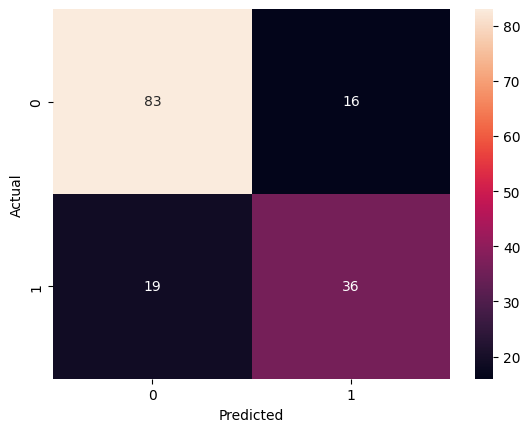

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
report

'              precision    recall  f1-score   support\n\n           0       0.81      0.84      0.83        99\n           1       0.69      0.65      0.67        55\n\n    accuracy                           0.77       154\n   macro avg       0.75      0.75      0.75       154\nweighted avg       0.77      0.77      0.77       154\n'

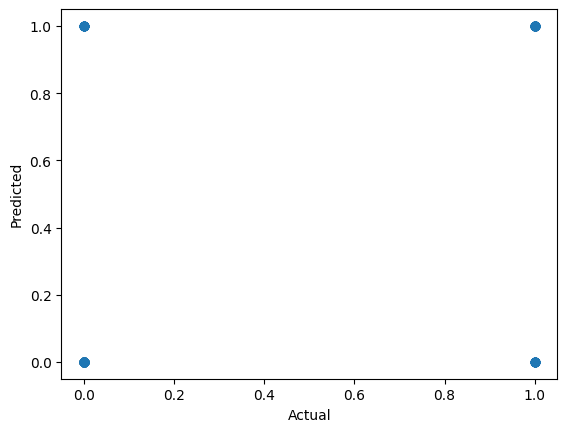

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_confusion = confusion_matrix(y_test, y_pred_knn)
knn_report = classification_report(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_accuracy}")
print(f"KNN Confusion Matrix:\n{knn_confusion}")
print(f"KNN Classification Report:\n{knn_report}")

KNN Accuracy: 0.6558441558441559
KNN Confusion Matrix:
[[67 32]
 [21 34]]
KNN Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        99
           1       0.52      0.62      0.56        55

    accuracy                           0.66       154
   macro avg       0.64      0.65      0.64       154
weighted avg       0.67      0.66      0.66       154



In [ ]:
from sklearn.svm import SVC

# Create an instance of the SVC classifier
svm_model = SVC()

# Train the SVM model using the scaled training data
svm_model.fit(x_train, y_train)

# Make predictions on the scaled test data
y_pred_svm = svm_model.predict(x_test)

# Calculate the accuracy score of the SVM model
svm_accuracy = accuracy_score(y_test, y_pred_svm)

# Print the accuracy score
print(f"SVM Accuracy: {svm_accuracy}")

SVM Accuracy: 0.7662337662337663


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

svm_confusion = confusion_matrix(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm)

print(f"SVM Confusion Matrix:\n{svm_confusion}")
print(f"SVM Classification Report:\n{svm_report}")

SVM Confusion Matrix:
[[87 12]
 [24 31]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_confusion = confusion_matrix(y_test, y_pred_nb)
nb_report = classification_report(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_accuracy}")
print(f"Naive Bayes Confusion Matrix:\n{nb_confusion}")
print(f"Naive Bayes Classification Report:\n{nb_report}")

Naive Bayes Accuracy: 0.7532467532467533
Naive Bayes Confusion Matrix:
[[78 21]
 [17 38]]
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tuned Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='entropy',     # better splitting
    max_depth=4,             # control overfitting
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7142857142857143
Confusion Matrix:
 [[66 33]
 [11 44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.67      0.75        99
           1       0.57      0.80      0.67        55

    accuracy                           0.71       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.76      0.71      0.72       154



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(2,10),
    'min_samples_split': range(2,10),
    'min_samples_leaf': range(1,6),
    'criterion': ['gini','entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [ ]:
y_pred_rf = model.predict(x_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_confusion = confusion_matrix(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"Random Forest Confusion Matrix:\n{rf_confusion}")
print(f"Random Forest Classification Report:\n{rf_report}")

Random Forest Accuracy: 0.7727272727272727
Random Forest Confusion Matrix:
[[83 16]
 [19 36]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

